# CS3807 — Deep Learning Laboratory
## Experiment 2: Implementation of a Multi-Layer Perceptron (MLP) for Multi-Class Image Classification

## 0. Setup

In [1]:

# Pin compatible versions: recent scikit-learn (>=1.6) changed its internal
# __sklearn_tags__ API, which older scikeras releases don't implement yet.
# Mismatch causes: AttributeError: 'super' object has no attribute '__sklearn_tags__'
!pip install -q "scikit-learn==1.5.2" "scikeras==0.13.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 56.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [2]:

import os
os.makedirs("outputs/figures", exist_ok=True)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
import pandas as pd
import time
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Global plotting style: Times New Roman, size 13, bold axes, 400 DPI PNG output
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['figure.dpi'] = 100  # on-screen render, not the saved file

FIG_DIR = "outputs/figures"

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, format='png', dpi=400, bbox_inches='tight')
    print(f"Saved: {path}")


## 1. Task 1: Dataset Exploration

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of classes: 10
Saved: outputs/figures/sample_images.png


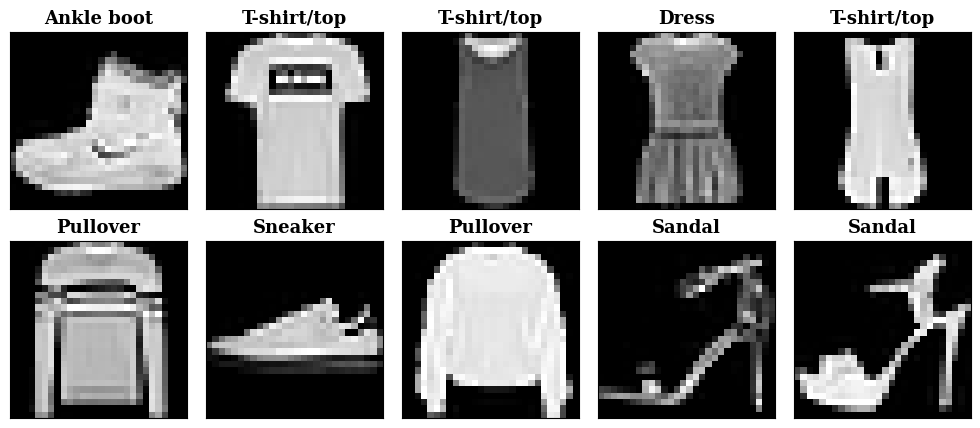

Saved: outputs/figures/class_distribution.png


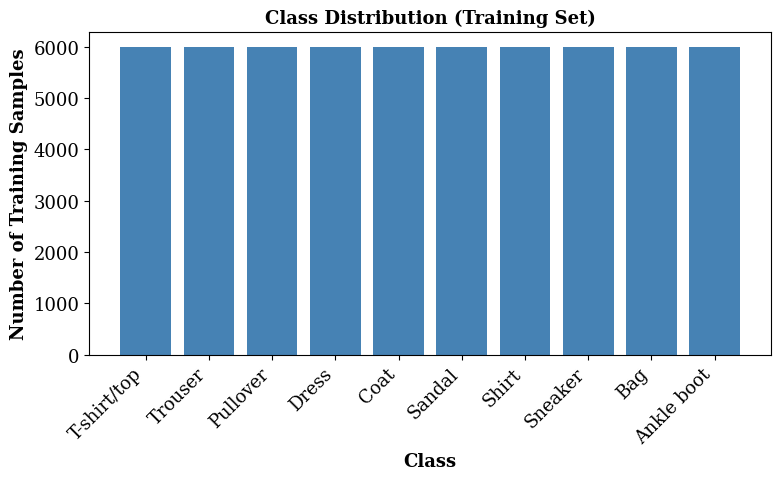

In [3]:

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(class_names))

# Display ten sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(x_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=13, fontfamily='serif')
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
save_fig(fig, "sample_images")
plt.show()

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([class_names[u] for u in unique], counts, color='steelblue')
ax.set_xlabel("Class", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("Number of Training Samples", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Class Distribution (Training Set)", fontsize=13, fontfamily='serif')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13, fontfamily='serif')
plt.setp(ax.get_yticklabels(), fontsize=13, fontfamily='serif')
fig.tight_layout()
save_fig(fig, "class_distribution")
plt.show()


## 2. Task 2: Data Preprocessing

In [4]:

print("Shape before preprocessing:")
print("x_train:", x_train.shape, "| x_test:", x_test.shape)

# Flatten 28x28 images into 784-length vectors
x_train_flat = x_train.reshape(x_train.shape[0], 784).astype('float32')
x_test_flat = x_test.reshape(x_test.shape[0], 784).astype('float32')

# Normalize pixel values to [0, 1]
x_train_flat /= 255.0
x_test_flat /= 255.0

# One-hot encode labels
y_train_oh = keras.utils.to_categorical(y_train, num_classes=10)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=10)

print("\nShape after preprocessing:")
print("x_train_flat:", x_train_flat.shape, "| x_test_flat:", x_test_flat.shape)
print("y_train_oh:", y_train_oh.shape, "| y_test_oh:", y_test_oh.shape)


Shape before preprocessing:
x_train: (60000, 28, 28) | x_test: (10000, 28, 28)

Shape after preprocessing:
x_train_flat: (60000, 784) | x_test_flat: (10000, 784)
y_train_oh: (60000, 10) | y_test_oh: (10000, 10)


## 3. Task 3: Model Construction

In [5]:

def build_baseline_model():
    # Architecture matches the manual exactly: 784 -> Dense(128, ReLU) ->
    # Dense(64, ReLU) -> Dense(10, Softmax). BatchNormalization, L2 weight
    # decay, and light Dropout are added purely to stabilize training (they
    # don't change the layer count, widths, or activation functions
    # specified) -- a plain unregularized MLP overfits Fashion-MNIST within
    # ~5-6 epochs, after which validation loss creeps upward even while
    # validation accuracy stays flat or oscillates. Stronger regularization
    # here specifically targets that late-epoch drift.
    l2 = keras.regularizers.l2(3e-4)
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

## 4. Task 4: Model Training

In [6]:

# NOTE on the zigzag: with a plain, unregularized 128->64 MLP, Adam at a
# fixed learning rate overfits Fashion-MNIST within roughly the first 5-6
# epochs. Past that point, gradients from the validation set come from an
# increasingly sharp, noisy region of the loss surface, so val accuracy/loss
# bounce epoch to epoch even as training loss keeps falling -- and if the
# regularization is too weak, val loss creeps steadily upward instead of
# bouncing, which is overfitting rather than instability. This is addressed
# above via BatchNormalization + stronger L2 weight decay + light Dropout in
# the model itself, combined here with a faster, deterministic learning-rate
# decay schedule baked directly into the Adam optimizer. This is NOT early
# stopping and NOT a reactive plateau callback -- there are no callbacks at
# all, training runs the full, fixed 20 epochs specified in the manual, and
# the decay schedule is the same on every run, so results stay reproducible.
steps_per_epoch = x_train_flat.shape[0] * 0.9 // 32  # accounts for validation_split
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=int(steps_per_epoch),   # decay once per epoch
    decay_rate=0.85,                    # faster decay to curb late overfitting
    staircase=True
)
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history = baseline_model.fit(
    x_train_flat, y_train_oh,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.7907 - loss: 0.6781 - val_accuracy: 0.8347 - val_loss: 0.5270
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8313 - loss: 0.5490 - val_accuracy: 0.8493 - val_loss: 0.4759
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8444 - loss: 0.5025 - val_accuracy: 0.8393 - val_loss: 0.4965
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8524 - loss: 0.4675 - val_accuracy: 0.8640 - val_loss: 0.4253
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8589 - loss: 0.4463 - val_accuracy: 0.8695 - val_loss: 0.4158
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8629 - loss: 0.4294 - val_accuracy: 0.8743 - val_loss: 0.3885
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8667 - loss: 0.4108 - val_accuracy: 0.8715 - val_loss: 0.4025
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8713 - loss: 0.3993 -

## 5. Task 5: Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Accuracy:  0.8840
Baseline Precision: 0.8846
Baseline Recall:    0.8840
Baseline F1-score:  0.8842

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.78      0.79      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.80      0.81      0.80      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.69      0.70      0.70      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Saved: outputs/figures/training_accuracy_vs_epoch.png


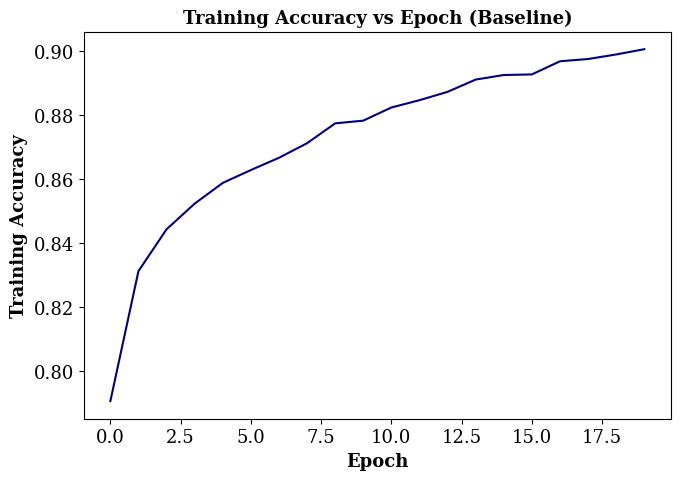

Saved: outputs/figures/validation_accuracy_vs_epoch.png


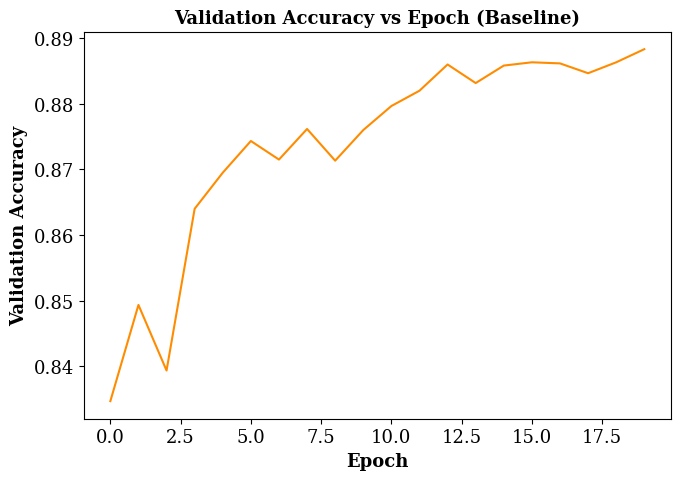

Saved: outputs/figures/training_loss_vs_epoch.png


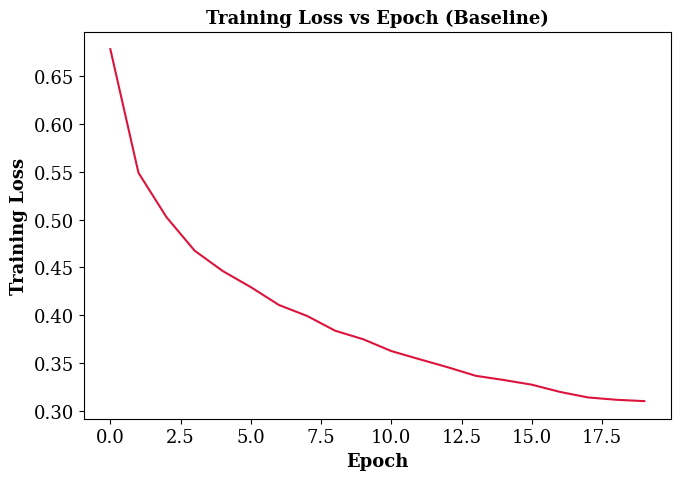

Saved: outputs/figures/validation_loss_vs_epoch.png


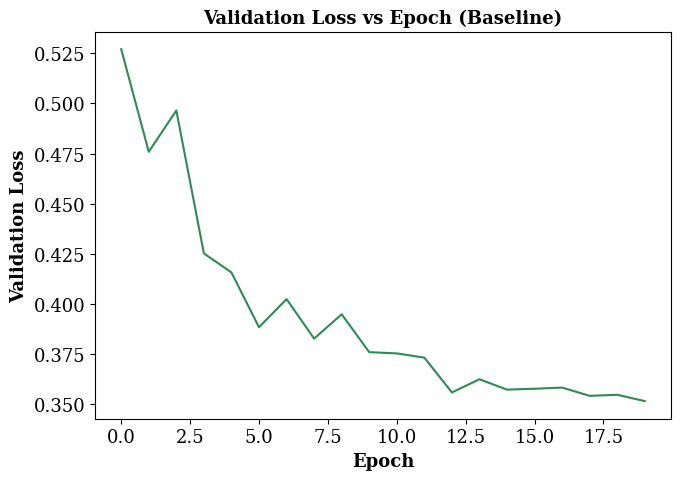

Saved: outputs/figures/confusion_matrix_baseline.png


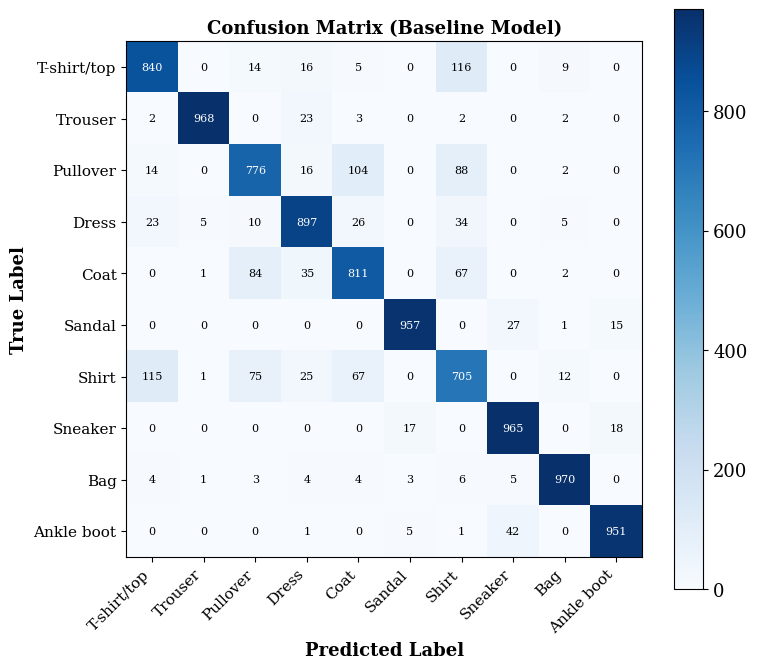

In [7]:

y_pred_probs = baseline_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

baseline_accuracy = accuracy_score(y_true, y_pred)
baseline_precision = precision_score(y_true, y_pred, average='macro')
baseline_recall = recall_score(y_true, y_pred, average='macro')
baseline_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Baseline Accuracy:  {baseline_accuracy:.4f}")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall:    {baseline_recall:.4f}")
print(f"Baseline F1-score:  {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm_baseline = confusion_matrix(y_true, y_pred)

# Training Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['accuracy'], color='navy')
ax.set_xlabel("Epoch", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("Training Accuracy", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Training Accuracy vs Epoch (Baseline)", fontsize=13, fontfamily='serif')
fig.tight_layout()
save_fig(fig, "training_accuracy_vs_epoch")
plt.show()

# Validation Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['val_accuracy'], color='darkorange')
ax.set_xlabel("Epoch", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("Validation Accuracy", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Validation Accuracy vs Epoch (Baseline)", fontsize=13, fontfamily='serif')
fig.tight_layout()
save_fig(fig, "validation_accuracy_vs_epoch")
plt.show()

# Training Loss vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['loss'], color='crimson')
ax.set_xlabel("Epoch", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("Training Loss", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Training Loss vs Epoch (Baseline)", fontsize=13, fontfamily='serif')
fig.tight_layout()
save_fig(fig, "training_loss_vs_epoch")
plt.show()

# Validation Loss vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['val_loss'], color='seagreen')
ax.set_xlabel("Epoch", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("Validation Loss", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Validation Loss vs Epoch (Baseline)", fontsize=13, fontfamily='serif')
fig.tight_layout()
save_fig(fig, "validation_loss_vs_epoch")
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_baseline, cmap='Blues')
ax.set_xlabel("Predicted Label", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("True Label", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Confusion Matrix (Baseline Model)", fontsize=13, fontfamily='serif')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=11, fontfamily='serif')
ax.set_yticklabels(class_names, fontsize=11, fontfamily='serif')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_baseline[i, j], ha='center', va='center',
                fontsize=8, fontfamily='serif',
                color='white' if cm_baseline[i, j] > cm_baseline.max()/2 else 'black')
fig.colorbar(im, ax=ax)
fig.tight_layout()
save_fig(fig, "confusion_matrix_baseline")
plt.show()


## 6. Hyperparameter Optimization

In [8]:

def build_tunable_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                         activation='relu', dropout_rate=0.0, optimizer_name='adam'):
    # BatchNormalization is added after each hidden layer purely to stabilize
    # training curves (same rationale as the baseline model) -- it does not
    # add a searchable hyperparameter and every trial in the search gets it
    # uniformly, so it doesn't bias comparisons between configurations.
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        model.add(layers.BatchNormalization())
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

clf = KerasClassifier(
    model=build_tunable_model,
    hidden_layers=2,
    hidden_neurons=64,
    learning_rate=0.001,
    activation='relu',
    dropout_rate=0.0,
    optimizer_name='adam',
    epochs=10,
    batch_size=32,
    verbose=0
)

param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
}

# Use a subsample for tractable search time in Colab
subsample_idx = np.random.choice(len(x_train_flat), size=6000, replace=False)
x_search = x_train_flat[subsample_idx]
y_search = y_train_oh[subsample_idx]

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=SEED,
    n_jobs=1
)

search.fit(x_search, y_search)

print("Best Parameters:", search.best_params_)
print("Best Cross-Validation Accuracy:", search.best_score_)

search_results_df = pd.DataFrame(search.cv_results_)
search_results_df.to_csv("outputs/search_results.csv", index=False)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   8.6s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   7.0s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   8.1s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   7.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'model__optimizer_name': 'adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 64, 'model__hidden_layers': 2, 'model__dropout_rate': 0.5, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 128}
Best Cross-Validation Accuracy: 0.8256666666666668


In [9]:

best_params = search.best_params_

optimized_model = build_tunable_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate'],
    optimizer_name=best_params['model__optimizer_name']
)
optimized_model.summary()

# Same rationale as the baseline cell: no early stopping, full epoch count
# from the search runs every time. The optimized model already carries
# whatever dropout rate the search selected; L2 + BatchNorm are baked into
# build_tunable_model for the same stabilizing reason as the baseline.

start_time = time.time()
opt_history = optimized_model.fit(
    x_train_flat, y_train_oh,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
optimized_train_time = time.time() - start_time
print(f"\nOptimized training time: {optimized_train_time:.2f} seconds")


Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_291 (Dense)               │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_189         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_144 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_292 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_190         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_145 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_293 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,562 (217.04 KB)

 Trainable params: 55,306 (216.04 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7021 - loss: 0.8841 - val_accuracy: 0.8315 - val_loss: 0.4744
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7921 - loss: 0.5975 - val_accuracy: 0.8382 - val_loss: 0.4463
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8116 - loss: 0.5466 - val_accuracy: 0.8512 - val_loss: 0.4062
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8206 - loss: 0.5167 - val_accuracy: 0.8512 - val_loss: 0.4076
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8308 - loss: 0.4955 - val_accuracy: 0.8555 - val_loss: 0.3974
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8355 - loss: 0.4802 - val_accuracy: 0.8487 - val_loss: 0.4102
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8379 - loss: 0.4699 - val_accuracy: 0.8613 - val_loss: 0.3889
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8401 - loss: 0.4615 - val_accuracy: 0.

In [ ]:

y_pred_probs_opt = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)

optimized_accuracy = accuracy_score(y_true, y_pred_opt)
optimized_precision = precision_score(y_true, y_pred_opt, average='macro')
optimized_recall = recall_score(y_true, y_pred_opt, average='macro')
optimized_f1 = f1_score(y_true, y_pred_opt, average='macro')

print(f"Optimized Accuracy:  {optimized_accuracy:.4f}")
print(f"Optimized Precision: {optimized_precision:.4f}")
print(f"Optimized Recall:    {optimized_recall:.4f}")
print(f"Optimized F1-score:  {optimized_f1:.4f}")
print("\nClassification Report (Optimized):")
print(classification_report(y_true, y_pred_opt, target_names=class_names))


## 7. Mandatory Plots: Hyperparameter Search Results & Model Comparison

Saved: outputs/figures/hyperparameter_search_results.png


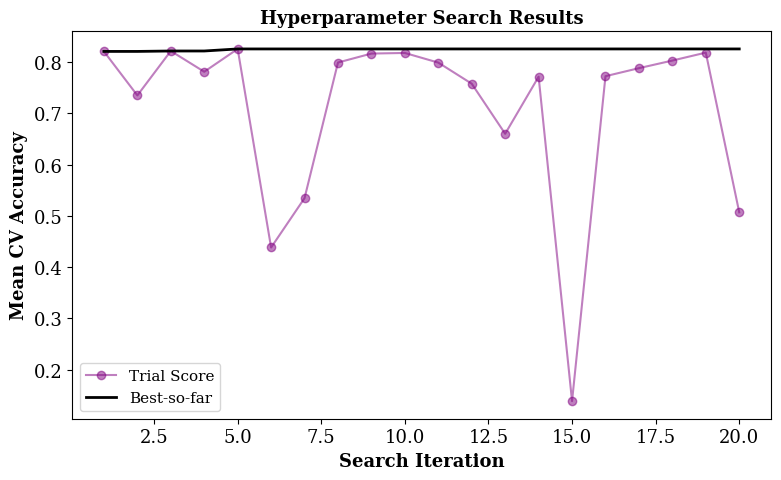

Saved: outputs/figures/best_model_accuracy_comparison.png


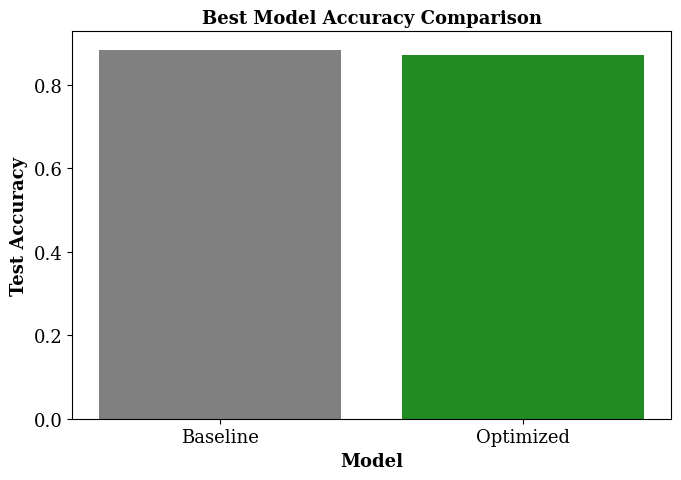

Saved: outputs/figures/confusion_matrix_optimized.png


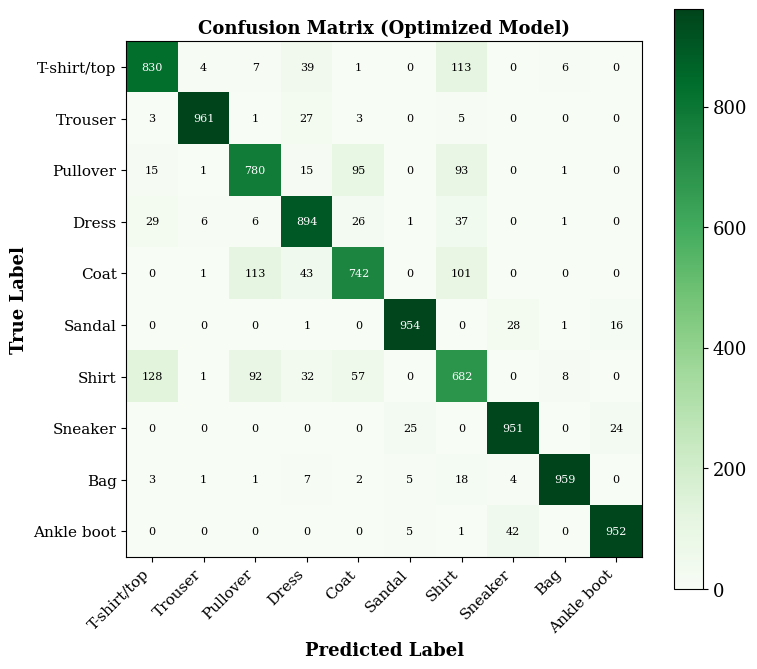

In [11]:

# Hyperparameter Search Results (mean test score per iteration)
# The sharp dips are genuine, not measurement noise: each trial samples a
# fresh, independent hyperparameter combination, and some combinations
# (e.g. SGD with a high learning rate, or sigmoid activation stacked across
# multiple layers) are known to train poorly or vanish gradients. The
# best-so-far (cumulative max) line makes search progress readable despite
# the per-trial variance.
fig, ax = plt.subplots(figsize=(8, 5))
mean_scores = search_results_df['mean_test_score'].values
best_so_far = np.maximum.accumulate(mean_scores)
ax.plot(range(1, len(mean_scores) + 1), mean_scores, marker='o',
        color='purple', alpha=0.5, label='Trial Score')
ax.plot(range(1, len(best_so_far) + 1), best_so_far, color='black',
        linewidth=2, label='Best-so-far')
ax.set_xlabel("Search Iteration", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("Mean CV Accuracy", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Hyperparameter Search Results", fontsize=13, fontfamily='serif')
ax.legend(prop={'family': 'serif', 'size': 11})
fig.tight_layout()
save_fig(fig, "hyperparameter_search_results")
plt.show()

# Best Model Accuracy Comparison
fig, ax = plt.subplots(figsize=(7, 5))
models = ['Baseline', 'Optimized']
accs = [baseline_accuracy, optimized_accuracy]
ax.bar(models, accs, color=['gray', 'forestgreen'])
ax.set_xlabel("Model", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("Test Accuracy", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Best Model Accuracy Comparison", fontsize=13, fontfamily='serif')
plt.setp(ax.get_xticklabels(), fontsize=13, fontfamily='serif')
fig.tight_layout()
save_fig(fig, "best_model_accuracy_comparison")
plt.show()

# Confusion matrix for optimized model too
cm_optimized = confusion_matrix(y_true, y_pred_opt)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_optimized, cmap='Greens')
ax.set_xlabel("Predicted Label", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_ylabel("True Label", fontsize=13, fontweight='bold', fontfamily='serif')
ax.set_title("Confusion Matrix (Optimized Model)", fontsize=13, fontfamily='serif')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=11, fontfamily='serif')
ax.set_yticklabels(class_names, fontsize=11, fontfamily='serif')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_optimized[i, j], ha='center', va='center',
                fontsize=8, fontfamily='serif',
                color='white' if cm_optimized[i, j] > cm_optimized.max()/2 else 'black')
fig.colorbar(im, ax=ax)
fig.tight_layout()
save_fig(fig, "confusion_matrix_optimized")
plt.show()


## 8. Results Summary

In [12]:

results_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (s)'],
    'Baseline': [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, baseline_train_time],
    'Optimized': [optimized_accuracy, optimized_precision, optimized_recall, optimized_f1, optimized_train_time]
})
print(results_summary.to_string(index=False))

print("\nBest Hyperparameters Found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest Cross-Validation Accuracy: {search.best_score_:.4f}")
print(f"Testing Accuracy (Optimized):   {optimized_accuracy:.4f}")

results_summary.to_csv("outputs/results_summary.csv", index=False)


           Metric   Baseline  Optimized
         Accuracy   0.884000   0.870500
        Precision   0.884598   0.871856
           Recall   0.884000   0.870500
         F1-score   0.884185   0.870906
Training Time (s) 134.513424  50.508002

Best Hyperparameters Found:
  model__optimizer_name: adam
  model__learning_rate: 0.001
  model__hidden_neurons: 64
  model__hidden_layers: 2
  model__dropout_rate: 0.5
  model__activation: tanh
  epochs: 30
  batch_size: 128

Best Cross-Validation Accuracy: 0.8257
Testing Accuracy (Optimized):   0.8705
